<a href="https://colab.research.google.com/github/AminaZahid/Urdu-Text-Sentiment-Analysis-using-ML-DL-algorithms/blob/main/Urdu_Text_SA_7_Algos_(6_ML%2C_1_DL%3DLSTM).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np 
import pandas as pd 
import os

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Import Data Preprocessing Libraries 
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Machine Learning Models
from sklearn import svm  
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
import xgboost as xgb

# Model Evaluation Libraries
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
!pip install urduhack

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.5/105.5 KB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 41.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 50.6 MB/s eta 0:00:00
  Attempting uninstall: tensorflow-datasets
    Found existing installation: tensorflow-datasets 4.8.2
    Uninstalling tensorflow-datasets-4.8.2:
      Successfully uninstalled tensorflow-datasets-4.8.2


# New Section

In [ ]:
import urduhack
urduhack.download()
from urduhack.normalization import normalize
from urduhack.preprocessing import normalize_whitespace, remove_punctuation, remove_accents, replace_urls, replace_emails, replace_numbers, replace_currency_symbols, remove_english_alphabets

89078/89078 [==============================] - 0s 5us/step


In [ ]:
train_data = pd.read_excel("/content/drive/MyDrive/UrduTextAnnotatedData.xlsx")
test_data = pd.read_excel("/content/drive/MyDrive/UrduTextAnnotatedData.xlsx")

In [ ]:
# Combine Both Files to Preprocess 
data =  pd.concat([train_data, test_data]).reset_index(drop=True)
print(data.shape)

(3014, 5)


In [ ]:
# Make copy of a dataset
df =  data.copy()
df.head()

,Review Id,Text,Annotator 1,Annotator 2,Annotator 3
0,1.0,بھنڈی بنائی تھی بہت اچھی بنی تھ,pos,pos,pos
1,2.0,آہاں نائس بارکان ویسے اس موسم میں بھنڈی,pos,pos,pos
2,3.0,سوری ہمارے لیے موسم کوئی معنے رکھتے لوکیشن اہم...,neu,neu,neu
3,4.0,چکن کڑاہی,neu,neu,neu
4,5.0,ہاں تو بنا کے ہی کھائی نا,neu,neu,neu


In [ ]:
# Make copy of Dataset to prepare for Word2Vector
df_w2v = df.copy() 

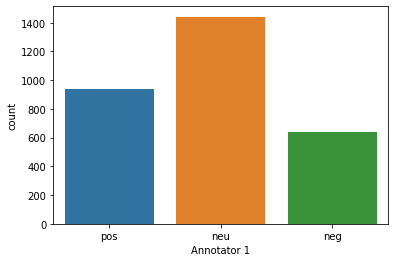

In [ ]:
sns.countplot( x = 'Annotator 1', data = df );

In [ ]:
# Encode the labels
le = LabelEncoder()
le.fit(df['Annotator 1'])
df['encoded_Annotator 1'] = le.transform(df['Annotator 1'])

In [ ]:
df['Text'] = df['Text'].apply(normalize) 
df['Text'] = df['Text'].apply(remove_accents) 
df['Text'] = df['Text'].apply(replace_urls) 
df['Text'] = df['Text'].apply(replace_emails)
df['Text'] = df['Text'].apply(replace_currency_symbols) 
df['Text'] = df['Text']

In [ ]:
from typing import FrozenSet

# Urdu Language Stop words list
STOP_WORDS: FrozenSet[str] = frozenset("""
 آ آئی آئیں آئے آتا آتی آتے آس آمدید آنا آنسہ آنی آنے آپ آگے آہ آہا آیا اب ابھی ابے
 ارے اس اسکا اسکی اسکے اسی اسے اف افوہ البتہ الف ان اندر انکا انکی انکے انہوں انہی انہیں اوئے اور اوپر
 اوہو اپ اپنا اپنوں اپنی اپنے اپنےآپ اکثر اگر اگرچہ اہاہا ایسا ایسی ایسے ایک بائیں بار بارے بالکل باوجود باہر
 بج بجے بخیر بشرطیکہ بعد بعض بغیر بلکہ بن بنا بناؤ بند بڑی بھر بھریں بھی بہت بہتر تاکہ تاہم تب تجھ
 تجھی تجھے ترا تری تلک تم تمام تمہارا تمہاروں تمہاری تمہارے تمہیں تو تک تھا تھی تھیں تھے تیرا تیری تیرے
 جا جاؤ جائیں جائے جاتا جاتی جاتے جانی جانے جب جبکہ جدھر جس جسے جن جناب جنہوں جنہیں جو جہاں جی جیسا
 جیسوں جیسی جیسے حالانکہ حالاں حصہ حضرت خاطر خالی خواہ خوب خود دائیں درمیان دریں دو دوران دوسرا دوسروں دوسری دوں
 دکھائیں دی دیئے دیا دیتا دیتی دیتے دیر دینا دینی دینے دیکھو دیں دیے دے ذریعے رکھا رکھتا رکھتی رکھتے رکھنا رکھنی
 رکھنے رکھو رکھی رکھے رہ رہا رہتا رہتی رہتے رہنا رہنی رہنے رہو رہی رہیں رہے ساتھ سامنے ساڑھے سب سبھی
 سراسر سمیت سوا سوائے سکا سکتا سکتے سہ سہی سی سے شاید شکریہ صاحب صاحبہ صرف ضرور طرح طرف طور علاوہ عین
 فقط فلاں فی قبل قطا لئے لائی لائے لاتا لاتی لاتے لانا لانی لانے لایا لو لوجی لوگوں لگ لگا لگتا
 لگتی لگی لگیں لگے لہذا لی لیا لیتا لیتی لیتے لیکن لیں لیے لے ماسوا مت مجھ مجھی مجھے محترم محترمہ محض
 مرا مرحبا مری مرے مزید مس مسز مسٹر مطابق مل مکرمی مگر مگھر مہربانی میرا میروں میری میرے میں نا نزدیک
 نما نہ نہیں نیز نیچے نے و وار واسطے واقعی والا والوں والی والے واہ وجہ ورنہ وغیرہ ولے وگرنہ وہ وہاں
 وہی وہیں ویسا ویسے ویں پاس پایا پر پس پلیز پون پونی پونے پھر پہ پہلا پہلی پہلے پیر پیچھے چاہئے
 چاہتے چاہیئے چاہے چلا چلو چلیں چلے چناچہ چند چونکہ چکی چکیں چکے ڈالنا ڈالنی ڈالنے ڈالے کئے کا کاش کب کبھی
 کدھر کر کرتا کرتی کرتے کرم کرنا کرنے کرو کریں کرے کس کسی کسے کم کن کنہیں کو کوئی کون کونسا
 کونسے کچھ کہ کہا کہاں کہہ کہی کہیں کہے کی کیا کیسا کیسے کیونکر کیونکہ کیوں کیے کے گئی گئے گا گنا
 گو گویا گی گیا ہائیں ہائے ہاں ہر ہرچند ہرگز ہم ہمارا ہماری ہمارے ہمی ہمیں ہو ہوئی ہوئیں ہوئے ہوا
 ہوبہو ہوتا ہوتی ہوتیں ہوتے ہونا ہونگے ہونی ہونے ہوں ہی ہیلو ہیں ہے یا یات یعنی یک یہ یہاں یہی یہیں
""".split())


def remove_stopwords(text: str):
    return " ".join(word for word in text.split() if word not in STOP_WORDS)

In [ ]:
len(STOP_WORDS)

430

In [ ]:
df[['Text']].head(10)

,Text
0,بھنڈی بنائی تھی بہت اچھی بنی تھ
1,آہاں نائس بارکان ویسے اس موسم میں بھنڈی
2,سوری ہمارے لیے موسم کوئی معنے رکھتے لوکیشن اہم...
3,چکن کڑاہی
4,ہاں تو بنا کے ہی کھائی نا
5,شکر قندی
6,صرف کھائی تھی۔
7,میں پکاتا نہیں ہوں۔
8,میں صرف لوگوں کا دماغ بول بول کے پکاتا ہوں، کھ...
9,بالکل آپ کے تو دستخط اتنے بڑے ہیں کہ ان کو پڑھ...


In [ ]:
from urduhack.models.lemmatizer import lemmatizer
def lemitizeStr(str):
    lemme_str = ""
    temp = lemmatizer.lemma_lookup(str)
    for t in temp:
        lemme_str += t[0] + " "
    
    return lemme_str

In [ ]:
df['Text'] =  df['Text'].apply(remove_stopwords)

In [ ]:
df['lemmatized_text'] = df['Text'].apply(lemitizeStr)

In [ ]:
df['Text'][2], df['lemmatized_text'][2]

('سوری موسم معنے لوکیشن اہم', 'سوری موسم معنے لوکیشن اہم ')

In [ ]:
df[['Text', 'lemmatized_text']].head(10)

,Text,lemmatized_text
0,بھنڈی بنائی اچھی بنی تھ,بھنڈی بنائی اچھی بنی تھ
1,آہاں نائس بارکان موسم بھنڈی,آہاں نائس بارکان موسم بھنڈی
2,سوری موسم معنے لوکیشن اہم,سوری موسم معنے لوکیشن اہم
3,چکن کڑاہی,چکن کڑاہی
4,کھائی,کھائی
5,شکر قندی,شکر قندی
6,کھائی تھی۔,کھائی تھی۔
7,پکاتا ہوں۔,پکاتا ہوں۔
8,دماغ بول بول پکاتا ہوں، کھانا,دماغ بول بول پکاتا ہوں، کھانا
9,دستخط اتنے بڑے پڑھنے ٹائم نکالنا پڑے گ,دستخط اتنے بڑے پڑھنے ٹائم نکالنا پڑے گ


In [ ]:
df.head()

,Review Id,Text,Annotator 1,Annotator 2,Annotator 3,encoded_Annotator 1,lemmatized_text
0,1.0,بھنڈی بنائی اچھی بنی تھ,pos,pos,pos,2,بھنڈی بنائی اچھی بنی تھ
1,2.0,آہاں نائس بارکان موسم بھنڈی,pos,pos,pos,2,آہاں نائس بارکان موسم بھنڈی
2,3.0,سوری موسم معنے لوکیشن اہم,neu,neu,neu,1,سوری موسم معنے لوکیشن اہم
3,4.0,چکن کڑاہی,neu,neu,neu,1,چکن کڑاہی
4,5.0,کھائی,neu,neu,neu,1,کھائی


In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(df['lemmatized_text'], df['encoded_Annotator 1'], test_size = 0.30, random_state = 7, shuffle = True)

In [ ]:
print('Shape of X_train', X_train.shape)
print('Shape of X_test', X_test.shape)
print('Shape of Y_train', Y_train.shape)
print('Shape of Y_test', Y_test.shape)

Shape of X_train (2109,)
Shape of X_test (905,)
Shape of Y_train (2109,)
Shape of Y_test (905,)


In [ ]:
max_feature_num = 50000
vectorizer = TfidfVectorizer(max_features=max_feature_num)
train_vecs = vectorizer.fit_transform(X_train)
test_vecs = TfidfVectorizer(max_features=max_feature_num, vocabulary=vectorizer.vocabulary_).fit_transform(X_test)

In [ ]:
train_vecs.shape, test_vecs.shape

((2109, 3170), (905, 3170))

In [ ]:
def SVM_classifier(train_vecs, Y_train, test_vecs, Y_test):
    # Training
    SVM = svm.LinearSVC(max_iter=100)
    SVM.fit(train_vecs, Y_train)

    # Testing
    test_predictionSVM = SVM.predict(test_vecs)
    return classification_report(test_predictionSVM, Y_test), confusion_matrix(test_predictionSVM, Y_test)

In [ ]:
def LR_classifier(train_vecs, Y_train, test_vecs, Y_test):
    # Training
    LR = LogisticRegression()
    LR.fit(train_vecs, Y_train)

    # testing
    test_predictionLR = LR.predict(test_vecs)
    return classification_report(test_predictionLR, Y_test) , confusion_matrix(test_predictionLR, Y_test)

In [ ]:
def DT_classifier(train_vecs, Y_train, test_vecs, Y_test):
    # Training
    DT = DecisionTreeClassifier(max_depth = 9, random_state = 23 )
    DT.fit(train_vecs, Y_train)

    # Testing
    test_predictionDT = DT.predict(test_vecs)
    return classification_report(test_predictionDT, Y_test), confusion_matrix(test_predictionDT, Y_test) 

In [ ]:
def XGB_classifier(train_vecs, Y_train, test_vecs, Y_test):
    # Training
    XGB = xgb.XGBClassifier(colsample_bytree = 0.2, learning_rate = 0.01, n_estimators = 100)
    XGB.fit(train_vecs, Y_train)

    # Testing
    test_predictionXGB = XGB.predict(test_vecs)
    return classification_report(test_predictionXGB, Y_test), confusion_matrix(test_predictionXGB, Y_test) 

In [ ]:
def RF_classifier(train_vecs, Y_train, test_vecs, Y_test):
    # Training
    RF = RandomForestClassifier(n_estimators = 450, max_depth=9, random_state=43)
    RF.fit(train_vecs, Y_train)

    # Testing
    test_predictionRF = RF.predict(test_vecs)
    return classification_report(test_predictionRF, Y_test), confusion_matrix(test_predictionRF, Y_test)

In [ ]:
class_report , conf_matrix = SVM_classifier(train_vecs, Y_train, test_vecs, Y_test)
print('Results of SVM CLASSIFIER on TF-IDF Vectorizer\n')
print(class_report)
print(conf_matrix)

Results of SVM CLASSIFIER on TF-IDF Vectorizer

              precision    recall  f1-score   support

           0       0.66      0.83      0.74       154
           1       0.91      0.85      0.88       460
           2       0.89      0.86      0.88       291

    accuracy                           0.85       905
   macro avg       0.82      0.85      0.83       905
weighted avg       0.86      0.85      0.85       905

[[128  20   6]
 [ 45 391  24]
 [ 20  20 251]]


In [ ]:
class_report , conf_matrix = LR_classifier(train_vecs, Y_train, test_vecs, Y_test)
print('Results of Logistic Regression Classifier on TF-IDF Vectorizer\n')
print(class_report)
print(conf_matrix)

Results of Logistic Regression Classifier on TF-IDF Vectorizer

              precision    recall  f1-score   support

           0       0.37      0.79      0.51        91
           1       0.91      0.69      0.79       570
           2       0.73      0.84      0.78       244

    accuracy                           0.74       905
   macro avg       0.67      0.77      0.69       905
weighted avg       0.81      0.74      0.76       905

[[ 72  16   3]
 [104 393  73]
 [ 17  22 205]]


In [ ]:
class_report , conf_matrix = DT_classifier(train_vecs, Y_train, test_vecs, Y_test)
print('Results of Decision Tree Classifier on TF-IDF Vectorizer\n')
print(class_report)
print(conf_matrix)

Results of Decision Tree Classifier on TF-IDF Vectorizer

              precision    recall  f1-score   support

           0       0.02      1.00      0.03         3
           1       0.98      0.55      0.71       771
           2       0.41      0.89      0.56       131

    accuracy                           0.60       905
   macro avg       0.47      0.81      0.43       905
weighted avg       0.90      0.60      0.68       905

[[  3   0   0]
 [182 424 165]
 [  8   7 116]]


In [ ]:
class_report , conf_matrix = XGB_classifier(train_vecs, Y_train, test_vecs, Y_test)
print('Results of Xgboost Classifier on TF-IDF Vectorizer\n')
print(class_report)
print(conf_matrix)

Results of Xgboost Classifier on TF-IDF Vectorizer

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.98      0.52      0.68       812
           2       0.28      0.86      0.43        93

    accuracy                           0.55       905
   macro avg       0.42      0.46      0.37       905
weighted avg       0.91      0.55      0.65       905

[[  0   0   0]
 [190 421 201]
 [  3  10  80]]


In [ ]:
class_report , conf_matrix = RF_classifier(train_vecs, Y_train, test_vecs, Y_test)
print('Results of Random Forest Classifier on TF-IDF Vectorizer\n')
print(class_report)
print(conf_matrix)

Results of Random Forest Classifier on TF-IDF Vectorizer

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.49      0.66       885
           2       0.07      1.00      0.13        20

    accuracy                           0.50       905
   macro avg       0.36      0.50      0.26       905
weighted avg       0.98      0.50      0.64       905

[[  0   0   0]
 [193 431 261]
 [  0   0  20]]


In [ ]:
df_w2v = df.copy() 

In [ ]:
df_w2v.head()

,Review Id,Text,Annotator 1,Annotator 2,Annotator 3,encoded_Annotator 1,lemmatized_text
0,1.0,بھنڈی بنائی اچھی بنی تھ,pos,pos,pos,2,بھنڈی بنائی اچھی بنی تھ
1,2.0,آہاں نائس بارکان موسم بھنڈی,pos,pos,pos,2,آہاں نائس بارکان موسم بھنڈی
2,3.0,سوری موسم معنے لوکیشن اہم,neu,neu,neu,1,سوری موسم معنے لوکیشن اہم
3,4.0,چکن کڑاہی,neu,neu,neu,1,چکن کڑاہی
4,5.0,کھائی,neu,neu,neu,1,کھائی


In [ ]:
import spacy
def tokenizer(str):
    nlp = spacy.blank('ur')
    doc = nlp.tokenizer(str)
    return [i.text for i in doc]
df_w2v["tokens"] = df_w2v["lemmatized_text"].apply(tokenizer)

In [ ]:
import gensim

model_word2vec = gensim.models.Word2Vec(sentences=df_w2v["tokens"], size=128, window=5, workers=10, min_count = 1)

In [ ]:
model_word2vec.wv.most_similar("مرد")

[('پاکستانی', 0.9961460828781128),
 ('بھائی', 0.9961458444595337),
 ('انڈے', 0.9961397051811218),
 ('کھانا', 0.9960867762565613),
 ('چاہیں', 0.9960641860961914),
 ('یمی', 0.996062695980072),
 ('جگہ', 0.9960576295852661),
 ('کھا', 0.9960275888442993),
 ('کھانے', 0.9960240125656128),
 ('وقت', 0.9960228204727173)]

In [ ]:
model_word2vec.wv.most_similar("بھنڈی")

[('؟', 0.9928035736083984),
 ('آج', 0.9927960634231567),
 ('اچھی', 0.9927487969398499),
 ('ہ', 0.9927393198013306),
 ('انڈہ', 0.9927371740341187),
 ('ترکیب', 0.9926990270614624),
 ('مصالحہ', 0.9926953911781311),
 ('بنے', 0.9926593899726868),
 ('دودھ', 0.992655873298645),
 ('استعمال', 0.9926418662071228)]

In [ ]:
model_word2vec.wv.most_similar("چکن")

[('،', 0.9997221827507019),
 ('ہیں', 0.9997081756591797),
 (')', 0.9996979832649231),
 ('انڈے', 0.9996888637542725),
 ('پانی', 0.9996874332427979),
 ('کھا', 0.999673068523407),
 ('زیادہ', 0.9996669888496399),
 ('ہے', 0.9996636509895325),
 ('(', 0.9996632933616638),
 ('وقت', 0.9996601343154907)]

In [ ]:
VOCAB_SIZE = len(model_word2vec.wv.vocab)
DIMENSIONS = 128
MAX_LEN = max([len(x) for x in df_w2v["tokens"]])

In [ ]:
VOCAB_SIZE, DIMENSIONS, MAX_LEN

(3451, 128, 103)

In [ ]:
from keras.preprocessing.text import Tokenizer
token = Tokenizer()
token.fit_on_texts(df_w2v["tokens"])
encoded = token.texts_to_sequences(df_w2v["tokens"])

In [ ]:
words2vec_matrix = np.zeros((VOCAB_SIZE+1,DIMENSIONS))
for word, index in token.word_index.items():
    try:
        words2vec_matrix[index] = model_word2vec.wv[word]
    except:
        print(index, word)

1435 milk
2065 advertisement
2074 marlboro
2075 capstan
2671 tea
2672 bag
2726 oatmeal
3380 low
3381 fat
3382 skim


In [ ]:
import tensorflow as tf
train_vectors = tf.keras.preprocessing.sequence.pad_sequences(encoded,padding='post',dtype=int)

In [ ]:
df.head()

,Review Id,Text,Annotator 1,Annotator 2,Annotator 3,encoded_Annotator 1,lemmatized_text
0,1.0,بھنڈی بنائی اچھی بنی تھ,pos,pos,pos,2,بھنڈی بنائی اچھی بنی تھ
1,2.0,آہاں نائس بارکان موسم بھنڈی,pos,pos,pos,2,آہاں نائس بارکان موسم بھنڈی
2,3.0,سوری موسم معنے لوکیشن اہم,neu,neu,neu,1,سوری موسم معنے لوکیشن اہم
3,4.0,چکن کڑاہی,neu,neu,neu,1,چکن کڑاہی
4,5.0,کھائی,neu,neu,neu,1,کھائی


In [ ]:
df.columns =['ID','Text','An1','An2','An3','enanot1','lemtxt']
df.head()

,ID,Text,An1,An2,An3,enanot1,lemtxt
0,1.0,بھنڈی بنائی اچھی بنی تھ,pos,pos,pos,2,بھنڈی بنائی اچھی بنی تھ
1,2.0,آہاں نائس بارکان موسم بھنڈی,pos,pos,pos,2,آہاں نائس بارکان موسم بھنڈی
2,3.0,سوری موسم معنے لوکیشن اہم,neu,neu,neu,1,سوری موسم معنے لوکیشن اہم
3,4.0,چکن کڑاہی,neu,neu,neu,1,چکن کڑاہی
4,5.0,کھائی,neu,neu,neu,1,کھائی


In [ ]:
df_w2v = df.copy()

In [ ]:
df_w2v.head()

,ID,Text,An1,An2,An3,enanot1,lemtxt
0,1.0,بھنڈی بنائی اچھی بنی تھ,pos,pos,pos,2,بھنڈی بنائی اچھی بنی تھ
1,2.0,آہاں نائس بارکان موسم بھنڈی,pos,pos,pos,2,آہاں نائس بارکان موسم بھنڈی
2,3.0,سوری موسم معنے لوکیشن اہم,neu,neu,neu,1,سوری موسم معنے لوکیشن اہم
3,4.0,چکن کڑاہی,neu,neu,neu,1,چکن کڑاہی
4,5.0,کھائی,neu,neu,neu,1,کھائی


In [ ]:
train_label = df_w2v.enanot1

In [ ]:
type(train_label[0])

numpy.int64

In [ ]:
(train_sentences,test_sentences, train_tags, test_tags) = train_test_split(train_vectors, train_label, test_size=0.2, shuffle = True)

In [ ]:
train_sentences

array([[ 584,  896,  139, ...,    0,    0,    0],
       [  41,  938, 3221, ...,    0,    0,    0],
       [  36,   34,    0, ...,    0,    0,    0],
       ...,
       [ 159, 2287,  824, ...,    0,    0,    0],
       [ 159,  370,  839, ...,    0,    0,    0],
       [   6,   45,  408, ...,    0,    0,    0]])

In [ ]:

import tensorflow.keras.layers as Layers
import tensorflow.keras.activations as Actications
import tensorflow.keras.models as Models
from tensorflow.keras.optimizers import Adam, Optimizer, SGD
import tensorflow.keras.initializers as Init
from tensorflow.keras import regularizers

In [ ]:
#LSTM
lstm = Models.Sequential()

lstm.add(Layers.Embedding(VOCAB_SIZE+1,DIMENSIONS,
                          embeddings_initializer = Init.Constant(words2vec_matrix),
                          input_length=MAX_LEN, trainable=False ))

lstm.add(Layers.Bidirectional(Layers.LSTM(256, activation='tanh')))

lstm.add(Layers.Dense(128, activation='tanh'))
lstm.add(Layers.Dropout(0.3))

lstm.add(Layers.Dense(64, activation='tanh'))
lstm.add(Layers.Dropout(0.3))

lstm.add(Layers.Dense(1, activation='sigmoid'))

lstm.summary()


Model: "sequential_10"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_9 (Embedding)     (None, 103, 128)          441856    
                                                                 
 bidirectional (Bidirectiona  (None, 512)              788480    
 l)                                                              
                                                                 
 dense_6 (Dense)             (None, 128)               65664     
                                                                 
 dropout_6 (Dropout)         (None, 128)               0         
                                                                 
 dense_7 (Dense)             (None, 64)                8256      
                                                                 
 dropout_7 (Dropout)         (None, 64)                0         
                                                     

In [ ]:
from keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import EarlyStopping
 

lstm.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
es_callback = EarlyStopping(monitor='val_loss', patience=3) 
LSTM_NET = lstm.fit(train_sentences, train_tags, epochs=10, validation_split=0.2, callbacks=[es_callback], shuffle=False)

Epoch 1/10
61/61 [==============================] - 79s 1s/step - loss: -0.9637 - accuracy: 0.4746 - val_loss: -1.2012 - val_accuracy: 0.5155
Epoch 2/10
61/61 [==============================] - 69s 1s/step - loss: -1.4525 - accuracy: 0.4772 - val_loss: -1.4497 - val_accuracy: 0.5155
Epoch 3/10
61/61 [==============================] - 56s 920ms/step - loss: -1.7070 - accuracy: 0.4772 - val_loss: -1.6825 - val_accuracy: 0.5155
Epoch 4/10
61/61 [==============================] - 55s 894ms/step - loss: -1.9779 - accuracy: 0.4772 - val_loss: -1.9134 - val_accuracy: 0.5155
Epoch 5/10
61/61 [==============================] - 55s 908ms/step - loss: -2.2125 - accuracy: 0.4772 - val_loss: -2.1401 - val_accuracy: 0.5155
Epoch 6/10
61/61 [==============================] - 53s 866ms/step - loss: -2.5054 - accuracy: 0.4772 - val_loss: -2.3706 - val_accuracy: 0.5155
Epoch 7/10
61/61 [==============================] - 53s 870ms/step - loss: -2.6997 - accuracy: 0.4772 - val_loss: -2.5954 - val_accuracy

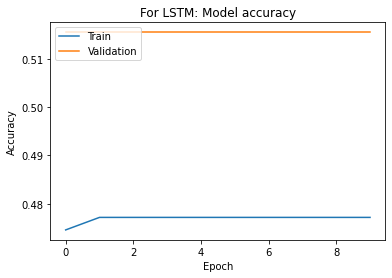

In [ ]:
plt.plot(LSTM_NET.history['accuracy'])
plt.plot(LSTM_NET.history['val_accuracy'])
plt.title('For LSTM: Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

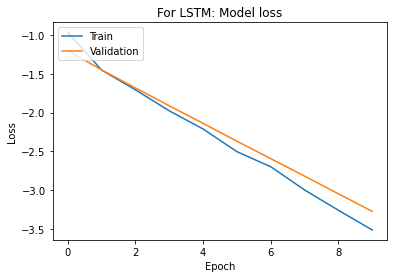

In [ ]:
plt.plot(LSTM_NET.history['loss'])
plt.plot(LSTM_NET.history['val_loss'])
plt.title('For LSTM: Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [ ]:
print(classification_report(lstm.predict(test_sentences).round(), test_tags))

19/19 [==============================] - 5s 231ms/step
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00         0
         1.0       1.00      0.45      0.62       603
         2.0       0.00      0.00      0.00         0

    accuracy                           0.45       603
   macro avg       0.33      0.15      0.21       603
weighted avg       1.00      0.45      0.62       603

